<a href="https://colab.research.google.com/github/sandotra1/Physics-Simulation-Collection/blob/main/Quantum_Tunneling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Quantum Tunneling Simulation  

## Simulation Overview

In this simulation, a Gaussian wave packet with defined momentum and spread propagates toward a potential barrier, and the evolution of its probability density \( |\psi(x)|^2 \) is animated over time. Key parameters like the barrier height, width, wave packet momentum, and spread can be adjusted to observe different tunneling behaviors.  

The visualization shows:  
- Reflected Wave
- Transmitted Wave  
- Probability Density    


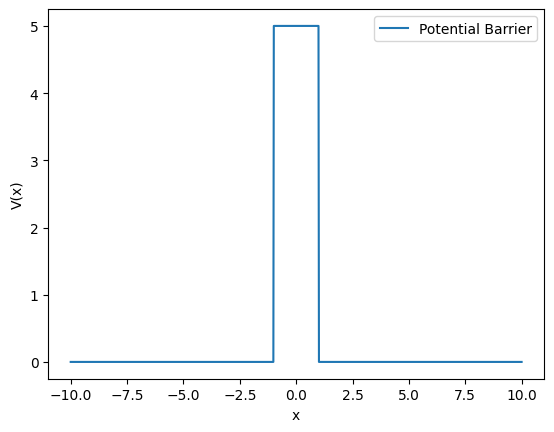

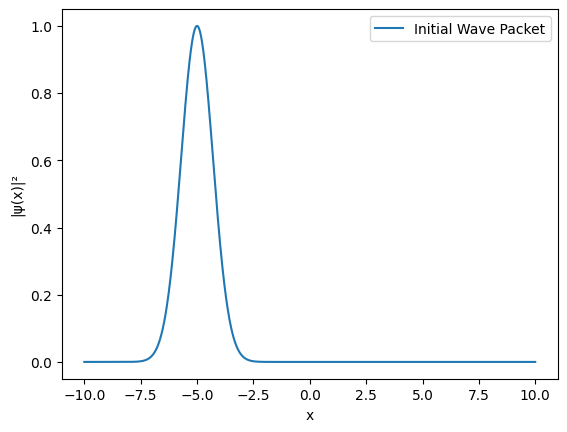

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import hbar, m_e
# Parameters
L = 10
N = 1000
x = np.linspace(-L, L, N)
V0 = 5
a = 2

# Potential barrier: V(x) = V0 within [-a/2, a/2], 0 otherwise
V = np.where(np.abs(x) <= a / 2, V0, 0)

plt.plot(x, V, label='Potential Barrier')
plt.xlabel('x')
plt.ylabel('V(x)')
plt.legend()
plt.show()


# Wave packet parameters
k0 = 3.0
sigma = 1.0
x0 = -5

# Initial wave function
psi = np.exp(-((x - x0) ** 2) / (2 * sigma ** 2)) * np.exp(1j * k0 * x)
plt.plot(x, np.abs(psi)**2, label='Initial Wave Packet')
plt.xlabel('x')
plt.ylabel('|ψ(x)|²')
plt.legend()
plt.show()

In [ ]:
#Takes about a minute to run (working on improving)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import matplotlib as mpl


mpl.rcParams['animation.embed_limit'] = 50


# Spatial domain and potential

L = 10
N = 700
x = np.linspace(-L, L, N)
dx = x[1] - x[0]


V0 = 10
a = 1
V = np.zeros(N)
V[(x > -a/2) & (x < a/2)] = V0


k0 = 5.0
sigma = 1.0
x0 = -5.0

# Gaussian wave packet with a plane wave factor:
psi = np.exp(-((x - x0)**2) / (2 * sigma**2)) * np.exp(1j * k0 * x)
psi /= np.sqrt(np.sum(np.abs(psi)**2))


dt = 0.005
T = 500
hbar = 1
m = 1


laplacian = -2 * np.eye(N) + np.eye(N, k=1) + np.eye(N, k=-1)
laplacian /= dx**2


H = - (hbar**2) / (2 * m) * laplacian + np.diag(V)


I = np.eye(N)

# Crank–Nicolson time evolution operator:

U = np.linalg.inv(I + 1j * H * dt / 2) @ (I - 1j * H * dt / 2)


scale = 50

fig, ax = plt.subplots()
ax.set_xlim(-L, L)
ax.set_ylim(0, 1.2)
ax.plot(x, V / V0 * 1.2, color='k', label='Potential Barrier', animated=True)  # Scale the barrier for visibility
(line,) = ax.plot(x, np.abs(psi) ** 2, color='b', label='|ψ(x)|²')
ax.legend()



def update(t):
    global psi
    psi = U @ psi
    psi /= np.sqrt(np.sum(np.abs(psi)**2))
    line.set_ydata(scale * np.abs(psi)**2)
    return (line,)


ani = FuncAnimation(fig, update, frames=T, blit=True, interval=10)
plt.close()

HTML(ani.to_jshtml())